# Anomaly detection using Isolation Forest

Current code will likely catch a big surge in the closing price—such as the one for BANANAS31/USDC on June 21st at around 16:00—as an anomaly.

Here's why:

IsolationForest is designed to detect outliers in the data, and a sudden, significant price surge will appear as an outlier compared to the surrounding values.
The code uses the closing price as the feature for anomaly detection, so any large, abrupt change (up or down) in the close price will be flagged as an anomaly.
After running the code, you can check the printed anomalies and the plot: red 'x' markers will indicate detected anomalies. If the surge at 16:00 on June 21st is much higher than the previous and following prices, it should be marked as an anomaly.

This uses 15m candlesticks, because it's better at detecting 1h candlestick predictions (1h candlesticks are composed of 4 quarters)

In [1]:
%pip install scikit-learn matplotlib requests pandas


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Number of anomalies detected: 5
                       close  close_pct_change
open_time                                     
2025-06-24 14:46:00  0.05397          0.009918
2025-06-24 10:47:00  0.05197          0.009322
2025-06-24 12:47:00  0.05357         -0.008881
2025-06-24 12:33:00  0.05311         -0.008587
2025-06-24 10:51:00  0.05134         -0.008306
Timestamps of detected anomalies:
DatetimeIndex(['2025-06-24 14:46:00', '2025-06-24 10:47:00',
               '2025-06-24 12:47:00', '2025-06-24 12:33:00',
               '2025-06-24 10:51:00'],
              dtype='datetime64[ns]', name='open_time', freq=None)


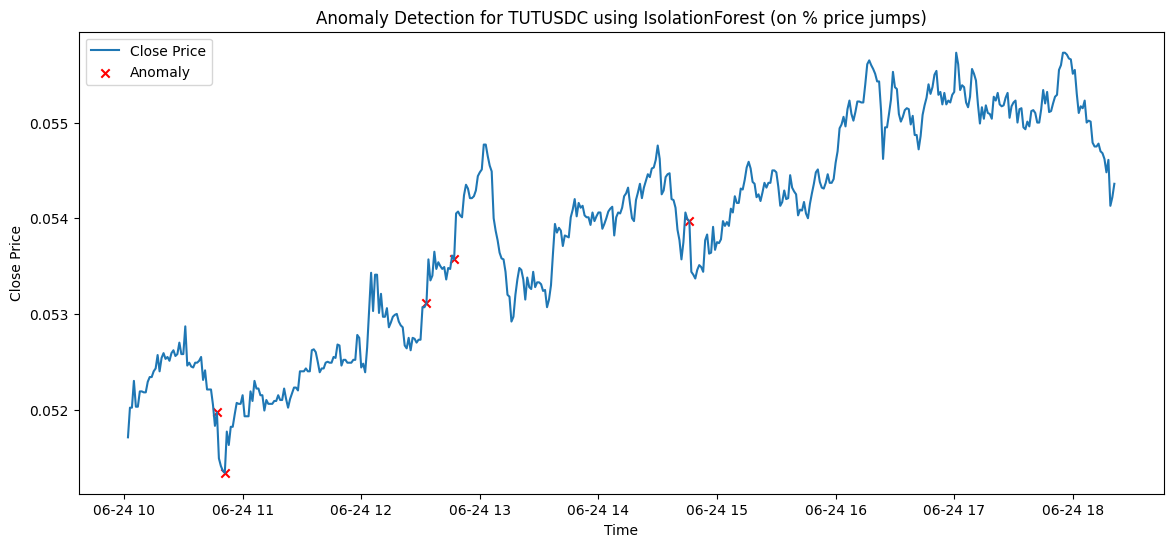

Model saved to ./checkpoints/isolation_forest_bananas31usdc.pkl


In [22]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import requests
import matplotlib.pyplot as plt
import joblib


# Parameters
symbol = 'TUTUSDC'
interval = '15m'

# Fetch klines from Binbot API
url = f'https://api.terminal.binbot.in/charts/timeseries?symbol={symbol}&interval={interval}'
response = requests.get(url)
data = response.json()
klines = data['data']

# Prepare DataFrame
df = pd.DataFrame(klines)

# Convert types
for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col] = df[col].astype(float)
df['open_time'] = pd.to_datetime(df['open_time'])
df.set_index('open_time', inplace=True)

# Calculate relative price change (percentage change)
df['close_pct_change'] = df['close'].pct_change().fillna(0)

# Use relative price change for anomaly detection
X = df[['close_pct_change']].values

# Fit IsolationForest (less sensitive)
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X)

# -1 indicates anomaly, 1 indicates normal
anomalies = df[df['anomaly'] == -1]
# Sort anomalies by absolute relative price change
anomalies_sorted = anomalies.reindex(anomalies['close_pct_change'].abs().sort_values(ascending=False).index)

print(f"Number of anomalies detected: {len(anomalies_sorted)}")
print(anomalies_sorted[['close', 'close_pct_change']])
print('Timestamps of detected anomalies:')
print(anomalies_sorted.index)

# Plot results
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['close'], label='Close Price')
plt.scatter(anomalies_sorted.index, anomalies_sorted['close'], color='red', label='Anomaly', marker='x')
plt.title(f'Anomaly Detection for {symbol} using IsolationForest (on % price jumps)')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Save the trained IsolationForest model to the checkpoints folder
joblib.dump(iso_forest, './checkpoints/isolation_forest_bananas31usdc.pkl')
print('Model saved to ./checkpoints/isolation_forest_bananas31usdc.pkl')


# Evaluate model with a different asset

Number of anomalies detected: 5
                       close  close_pct_change
open_time                                     
2025-06-24 14:46:00  0.05397          0.009918
2025-06-24 10:47:00  0.05197          0.009322
2025-06-24 12:47:00  0.05357         -0.008881
2025-06-24 12:33:00  0.05311         -0.008587
2025-06-24 10:51:00  0.05134         -0.008306
Timestamps of detected anomalies:
DatetimeIndex(['2025-06-24 14:46:00', '2025-06-24 10:47:00',
               '2025-06-24 12:47:00', '2025-06-24 12:33:00',
               '2025-06-24 10:51:00'],
              dtype='datetime64[ns]', name='open_time', freq=None)


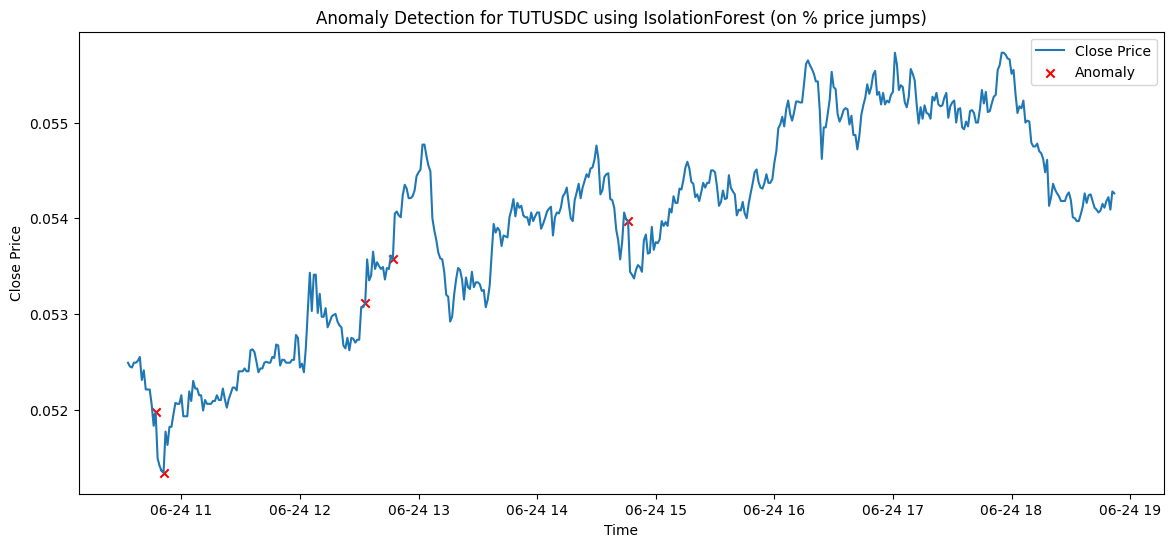

Model saved to ./checkpoints/isolation_forest_anomalies.pkl


In [24]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import requests
import matplotlib.pyplot as plt
import joblib


# Parameters
symbol = 'TUTUSDC'
interval = '15m'

# Fetch klines from Binbot API
url = f'https://api.terminal.binbot.in/charts/timeseries?symbol={symbol}&interval={interval}'
response = requests.get(url)
data = response.json()
klines = data['data']

# Prepare DataFrame
df = pd.DataFrame(klines)

# Convert types
for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col] = df[col].astype(float)
df['open_time'] = pd.to_datetime(df['open_time'])
df.set_index('open_time', inplace=True)

# Calculate relative price change (percentage change)
df['close_pct_change'] = df['close'].pct_change().fillna(0)

# Use relative price change for anomaly detection
X = df[['close_pct_change']].values

# Fit IsolationForest (less sensitive)
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X)

# -1 indicates anomaly, 1 indicates normal
anomalies = df[df['anomaly'] == -1]
# Sort anomalies by absolute relative price change
anomalies_sorted = anomalies.reindex(anomalies['close_pct_change'].abs().sort_values(ascending=False).index)

print(f"Number of anomalies detected: {len(anomalies_sorted)}")
print(anomalies_sorted[['close', 'close_pct_change']])
print('Timestamps of detected anomalies:')
print(anomalies_sorted.index)

# Plot results
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['close'], label='Close Price')
plt.scatter(anomalies_sorted.index, anomalies_sorted['close'], color='red', label='Anomaly', marker='x')
plt.title(f'Anomaly Detection for {symbol} using IsolationForest (on % price jumps)')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Save the trained IsolationForest model to the checkpoints folder
joblib.dump(iso_forest, './checkpoints/isolation_forest_anomalies.pkl')
print('Model saved to ./checkpoints/isolation_forest_anomalies.pkl')


## Production bundle

In [27]:
import joblib
import pandas as pd
import requests

# Load the model from the checkpoints folder
loaded_model = joblib.load('./checkpoints/isolation_forest_anomalies.pkl')

# Parameters
symbol = 'TUTUSDC'
interval = '15m'

# Fetch klines from Binbot API
url = f'https://api.terminal.binbot.in/charts/timeseries?symbol={symbol}&interval={interval}'
response = requests.get(url)
data = response.json()
klines = data['data']

# Prepare DataFrame
df = pd.DataFrame(klines)

# Convert types
for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col] = df[col].astype(float)
df['open_time'] = pd.to_datetime(df['open_time'])
df.set_index('open_time', inplace=True)

# Calculate relative price change (percentage change)
df['close_pct_change'] = df['close'].pct_change().fillna(0)

# Use relative price change for anomaly detection
X = df[['close_pct_change']].values

# Predict anomalies using the loaded model
predictions = loaded_model.predict(X)
df['anomaly_loaded'] = predictions
anomalies_loaded = df[df['anomaly_loaded'] == -1]

print(f"Number of anomalies detected by loaded model: {len(anomalies_loaded)}")
print(anomalies_loaded[['close', 'close_pct_change']])
print('Timestamps of detected anomalies:')
print(anomalies_loaded.index)

Number of anomalies detected by loaded model: 5
                       close  close_pct_change
open_time                                     
2025-06-24 14:46:00  0.05397          0.009918
2025-06-24 12:47:00  0.05357         -0.008881
2025-06-24 12:33:00  0.05311         -0.008587
2025-06-24 10:51:00  0.05134         -0.008306
2025-06-24 10:47:00  0.05197          0.009322
Timestamps of detected anomalies:
DatetimeIndex(['2025-06-24 14:46:00', '2025-06-24 12:47:00',
               '2025-06-24 12:33:00', '2025-06-24 10:51:00',
               '2025-06-24 10:47:00'],
              dtype='datetime64[ns]', name='open_time', freq=None)
